Classifier 1
              precision    recall  f1-score   support

           A       0.67      1.00      0.80         6
           B       1.00      0.62      0.77         8

    accuracy                           0.79        14
   macro avg       0.83      0.81      0.78        14
weighted avg       0.86      0.79      0.78        14

Classifier 2
              precision    recall  f1-score   support

           A       0.71      0.83      0.77         6
           B       0.86      0.75      0.80         8

    accuracy                           0.79        14
   macro avg       0.79      0.79      0.78        14
weighted avg       0.80      0.79      0.79        14

Classifier 3
              precision    recall  f1-score   support

           A       0.71      0.83      0.77         6
           B       0.86      0.75      0.80         8

    accuracy                           0.79        14
   macro avg       0.79      0.79      0.78        14
weighted avg       0.80      0.79  

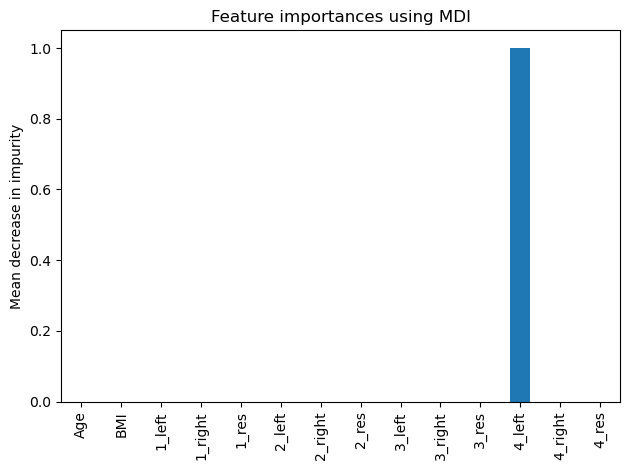

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import *
from dtreeviz import model
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier








Treatment=pd.read_csv("../AD report/AB.csv")

class_names=["A","B"]

fullinfo=True
fulltree=False

def class1_1():
    Treatment=pd.read_csv("../AD report/AB_1 train.csv")
    Treatment_test=pd.read_csv("../AD report/AB_1 test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    clf=XGBClassifier(tree_method="hist",
                      eta=0.5,
                      objective="reg:pseudohubererror",
                      max_delta_step=0.2,
                      grow_policy="lossguide",
                        random_state=89,
                     
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5)
    print("Classifier 1")
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))   
    if fulltree==True:
        clf.fit(X_train, y_train)
        plt.figure(figsize=(400, 120))
        plot_tree(clf)
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2


def class2_1():
    Treatment=pd.read_csv("../AD report/AB_2 train.csv")
    Treatment_test=pd.read_csv("../AD report/AB_2 test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    
    
    R_state=random.randrange(1,100)
    R_state=59
    clf=XGBClassifier(tree_method="approx",
                      eta=0.5,
                      objective="reg:squaredlogerror",
                      max_delta_step=0.2,
                      grow_policy="lossguide",
                      random_state=R_state,
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5)
    print("Classifier 2")
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names)) 
    if fulltree==True:
        clf.fit(X_train, y_train)
        plt.figure(figsize=(400, 120))
        plot_tree(clf)
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2

def class3_1():
    Treatment=pd.read_csv("../AD report/AB_3 train.csv")
    Treatment_test=pd.read_csv("../AD report/AB_3 test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    
    R_state=random.randrange(1,100)
    
    R_state=59
    clf=XGBClassifier(updater="coord_descent",
                      booster="gblinear",
                      feature_selector="thrifty", 
                      objective="reg:squarederror", 
                      random_state=3,
                      top_k=4,
                      
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    print("Classifier 3")
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))      
    
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2
    

def class4_1():
    Treatment=pd.read_csv("../AD report/AB train.csv")
    Treatment_test=pd.read_csv("../AD report/AB test.csv")

    X_train=Treatment.iloc[:,1:]
    y_train=Treatment.iloc[:,0]

    X_test=Treatment_test.iloc[:,1:]
    y_test=Treatment_test.iloc[:,0]
    
    
    clf=XGBClassifier(updater="shotgun",
                      booster="gblinear",
                      feature_selector="cyclic", 
                      #objective="reg:pseudohubererror", 
                      random_state=3,
                      
                                           
                     )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    print("Classifier 4")
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))  
    
    accuracy = accuracy_score(y_test, y_pred)
    y_pred1 = clf.predict_proba(X_train)
    y_pred = clf.predict(X_train)
    y_pred3 = clf.predict_proba(X_test)
    y_pred2 = clf.predict(X_test) 
    return y_pred1, y_pred,y_pred3, y_pred2
    
def VoteClass_1():

    y_train=pd.read_csv("../AD report/Full AB.csv")
    y_test=pd.read_csv("../AD report/Full AB test.csv")
    
    new_data, n_data,new_test,n_test=class1_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([y_train, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([y_test, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)

    
    new_data, n_data,new_test,n_test=class2_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)
    
    new_data, n_data,new_test,n_test=class3_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)
    
    new_data, n_data,new_test,n_test=class4_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, new_data], axis=1)
    dat1 = pd.concat([dat1, n_data], axis=1)
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, new_test], axis=1)
    dat2 = pd.concat([dat2, n_test], axis=1)
    
    dat1.columns = ["ID","Age","BMI", "1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res","4_left", "4_right","4_res"]
    dat2.columns = ["ID","Age","BMI", "1_left", "1_right","1_res","2_left", "2_right","2_res","3_left", "3_right","3_res","4_left", "4_right","4_res"]

    X_train=dat1.iloc[:,1:]
    y_train=dat1.iloc[:,0]

    X_test=dat2.iloc[:,1:]
    y_test=dat2.iloc[:,0]
    
    R_state=random.randrange(1,1000)
    R_state=975
    print("THE: ",R_state)
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~Random 1~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    clf1 = RandomForestClassifier(max_depth=7, 
                                 random_state=R_state,
                                # bootstrap=False,
                              # warm_start=True,
                                 class_weight="balanced_subsample",
                                 n_estimators=301,
                                 
                                criterion="entropy",
                                # n_jobs=5,
                                )
    
    clf1.fit(X_train,y_train)
    y_pred = clf1.predict(X_test)
    y_pred = (y_pred > 0.5) 
  #  print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names)) 
    accuracy = accuracy_score(y_test, y_pred)
 #   print("Accuracy:", (accuracy*100),"%")
  #  print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~Random 2~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    
    clf2 = DecisionTreeClassifier(criterion="entropy",
                                 random_state=R_state,
                                  class_weight="balanced"
                                )
    
    clf2.fit(X_train,y_train)
    y_pred = clf2.predict(X_test)
    y_pred = (y_pred > 0.5) 
  #  print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names)) 
    accuracy = accuracy_score(y_test, y_pred)
   # print("Accuracy:", (accuracy*100),"%")
   # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~XGB 3~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    
    clf3=XGBClassifier(tree_method="exact", 
                     random_state=R_state,
                     )
    clf3.fit(X_train, y_train)
    y_pred = clf3.predict(X_test)
    y_pred = (y_pred > 0.5)
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names)) 
    names=clf3.get_booster().feature_names
    importances = clf2.feature_importances_
    forest_importances = pd.Series(importances, index=names)
    fig, ax = plt.subplots()
    forest_importances.plot.bar( ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    accuracy = accuracy_score(y_test, y_pred)
   # print("Accuracy:", (accuracy*100),"%")
   # print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    
    
    
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print("Combined classifier")
    print(classification_report(y_test,y_pred,output_dict=False,target_names=["A","B"]))
    
    accuracy = accuracy_score(y_test, y_pred)
    print("Overall accuracy")
    print("Accuracy:", (accuracy*100),"%")
    
    
    
    
    
    
    
   
    
    
    
    
    
#class1_1()
VoteClass_1()




